# 🏋️ Kinetics Video Action Recognition Training

This notebook is specifically designed and optimized to prevent **Overfitting** and **Domain Shift** by incorporating modern Computer Vision best practices:
- **ResNet50 Preprocess Input**: Properly normalizes pixel data using ImageNet weights instead of blindly dividing by 255.0.
- **Center-Cropping**: Trims videos into perfect squares before passing them to the AI, ensuring 9:16 vertical phone videos and 16:9 widescreen videos are not heavily distorted (squished), which historically destroyed inference accuracy.
- **Focused Temporal Sampling**: Trims 16 frames solely from the middle 4 seconds of long videos to ensure the AI actually sees dense action instead of just staring at the background.
- **L2 Regularization & Heavy Dropout**: Prevents the LSTM layers from simply memorizing specific colors and forces it to understand temporal relationships.


In [2]:
import os
import gc
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

print("TensorFlow version:" , tf.__version__)
print("GPU AVAILABLE:" , tf.config.list_physical_devices('GPU'))

2026-06-27 18:51:12.643252: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782586272.897113      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782586272.965632      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782586273.582299      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782586273.582338      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782586273.582341      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU AVAILABLE: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# 👉 UPDATE THIS PATH TO YOUR KINETICS DATASET FOLDER ON KAGGLE!
# Once you click "Add Data" and attach a kinetics dataset, copy its path here.
DATA_PATH = "/kaggle/input/datasets/pypiahmad/realistic-action-recognition-ucf50/UCF50"

# We automatically load all folders (classes) available in the dataset
all_classes = sorted([d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))])
print(f"Found {len(all_classes)} Total Classes in Dataset.")

# To keep RAM usage safe on Kaggle (30GB limit), we limit to the first 50 classes for this run.
# You can increase this if Kaggle's memory allows it!
MAX_CLASSES_TO_USE = 50
SELECTED_CLASSES = all_classes[:MAX_CLASSES_TO_USE]

print(f"\nUsing {len(SELECTED_CLASSES)} Classes.")
class_to_idx = {clas: idx for idx, clas in enumerate(SELECTED_CLASSES)}

Found 50 Total Classes in Dataset.

Using 50 Classes.


In [4]:
IMG_SIZE = 224
NUM_FRAMES = 30 # Increased from 16 to 30 for better performance!

# ── STEP 1: Load Pretrained ResNet50 ──────────────────────────────
base_cnn = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# We completely freeze ResNet50 to act only as a feature extractor
for layer in base_cnn.layers:
    layer.trainable = False

cnn_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
cnn_out = base_cnn(cnn_input, training=False) # entering into reset50 pokemon
cnn_out = GlobalAveragePooling2D()(cnn_out)
cnn_model = Model(cnn_input, cnn_out, name='CNN_FeatureExtractor')

print('✅ ResNet50 loaded and completely frozen.')
print(f'Trainable params: {cnn_model.count_params():,}')  # Should be 0

I0000 00:00:1782586289.046562      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782586289.052673      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ ResNet50 loaded and completely frozen.
Trainable params: 23,587,712


In [5]:
def extract_frames_and_features(video_path, cnn_model, num_frames=30, img_size=224):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    # Focus on the middle of the video (max 150 frames) to prevent diluting the action!
    MAX_ACTION_FRAMES = 150
    if total_frames <= MAX_ACTION_FRAMES:
        start_frame = 0
        end_frame = total_frames - 1
    else:
        start_frame = (total_frames - MAX_ACTION_FRAMES) // 2
        end_frame = start_frame + MAX_ACTION_FRAMES - 1
        
    frame_indices = np.linspace(start_frame, end_frame, num_frames, dtype=int)
    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            # 1. Center crop to prevent fat/stretched people on mobile videos!
            h, w = frame.shape[:2]
            min_dim = min(h, w)
            start_x = (w - min_dim) // 2
            start_y = (h - min_dim) // 2
            frame = frame[start_y:start_y+min_dim, start_x:start_x+min_dim]
            
            # 2. Resize
            frame = cv2.resize(frame, (img_size, img_size))
            
            # 3. Convert BGR → RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        else:
            frames.append(np.zeros((img_size, img_size, 3)))

    cap.release()
    frames = np.array(frames, dtype=np.float32)

    # ✨ CRITICAL FIX: Use ResNet50's official preprocess_input instead of / 255.0
    # This prevents the AI from getting confused by out-of-distribution colors.
    frames = preprocess_input(frames)

    # Extract CNN Features immediately to save RAM!
    features = cnn_model.predict(frames, verbose=0)
    return features

In [6]:
# ── STEP 2: Process ALL Videos → Store Only CNN Features ───────────
all_features = []
all_labels = []

print('Extracting CNN features from all videos...\n')

for class_name in SELECTED_CLASSES:
    class_folder = os.path.join(DATA_PATH, class_name)
    if not os.path.exists(class_folder): continue
        
    video_files = os.listdir(class_folder)
    # Limit to 100 videos per class to save time during this run
    video_files = video_files[:100] 
    
    label = class_to_idx[class_name]
    print(f'Processing: {class_name} ({len(video_files)} videos)')

    for video_file in tqdm(video_files):
        video_path = os.path.join(class_folder, video_file)
        features = extract_frames_and_features(video_path, cnn_model, NUM_FRAMES, IMG_SIZE)
        
        if features is not None and len(features) == NUM_FRAMES:
            all_features.append(features)
            all_labels.append(label)

X = np.array(all_features, dtype=np.float32)
y = np.array(all_labels, dtype=np.int32)

print(f'\n✅ Extraction Complete! Memory usage: {X.nbytes / 1e6:.1f} MB')

Extracting CNN features from all videos...

Processing: BaseballPitch (100 videos)


  0%|          | 0/100 [00:00<?, ?it/s]

I0000 00:00:1782586294.705231     131 service.cc:152] XLA service 0x78bb38004d70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782586294.705270     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782586294.705274     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782586295.539216     131 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782586299.775378     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Processing: Basketball (100 videos)


  0%|          | 0/100 [00:00<?, ?it/s]

...

Processing: WalkingWithDog (100 videos)


  0%|          | 0/100 [00:00<?, ?it/s]

Processing: YoYo (100 videos)


  0%|          | 0/100 [00:00<?, ?it/s]


✅ Extraction Complete! Memory usage: 1228.8 MB


In [7]:
NUM_CLASSES = len(SELECTED_CLASSES)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

y_train = to_categorical(y_train, NUM_CLASSES)
y_val = to_categorical(y_val, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)

print('Split summary:')
print(f'  X_train : {X_train.shape}')
print(f'  X_val   : {X_val.shape}')
print(f'  X_test  : {X_test.shape}')

Split summary:
  X_train : (4000, 30, 2048)
  X_val   : (500, 30, 2048)
  X_test  : (500, 30, 2048)


In [8]:
FEATURE_DIM = 2048

# ── BUILD MODEL WITH REGULARIZATION ─────────────────────────────────────
model = Sequential([
    LSTM(128, input_shape=(NUM_FRAMES, FEATURE_DIM), return_sequences=True, 
         kernel_regularizer=regularizers.l2(0.001)), # L2 Prevents memorization
    
    Dropout(0.4), # Increased Dropout to prevent overfitting

    LSTM(64, return_sequences=False, kernel_regularizer=regularizers.l2(0.001)),
    
    Dropout(0.4),
    
    BatchNormalization(),
    
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    
    Dropout(0.3),
    
    Dense(NUM_CLASSES, activation='softmax')
], name="Kinetics_ActionNet")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Kinetics_ActionNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │     1,114,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         3,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,171,698 (4.47 MB)

 Trainable params: 1,171,570 (4.47 MB)

 Non-trainable params: 128 (512.00 B)

In [9]:
callbacks = [
    ModelCheckpoint('kinetics_best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=10, verbose=1, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training Complete! Your highly generalized Kinetics model is ready!")

Epoch 1/100
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0337 - loss: 5.0984
Epoch 1: val_accuracy improved from None to 0.20400, saving model to kinetics_best_model.keras

Epoch 1: finished saving model to kinetics_best_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.0585 - loss: 4.9386 - val_accuracy: 0.2040 - val_loss: 4.6090 - learning_rate: 1.0000e-04
Epoch 2/100
122/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1197 - loss: 4.5341
Epoch 2: val_accuracy improved from 0.20400 to 0.44000, saving model to kinetics_best_model.keras

Epoch 2: finished saving model to kinetics_best_model.keras
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1462 - loss: 4.4293 - val_accuracy: 0.4400 - val_loss: 4.1764 - learning_rate: 1.0000e-04
Epoch 3/100
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2215 - loss: 4.1122
Epoch 3: val_accuracy improved from 0.44000 to 0.57000, saving model to kinetics_best_model.keras

Epoch 3: finished saving model

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print(f"\nTest Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9540 - loss: 0.7237

Test Accuracy : 0.9540
Test Loss     : 0.7237


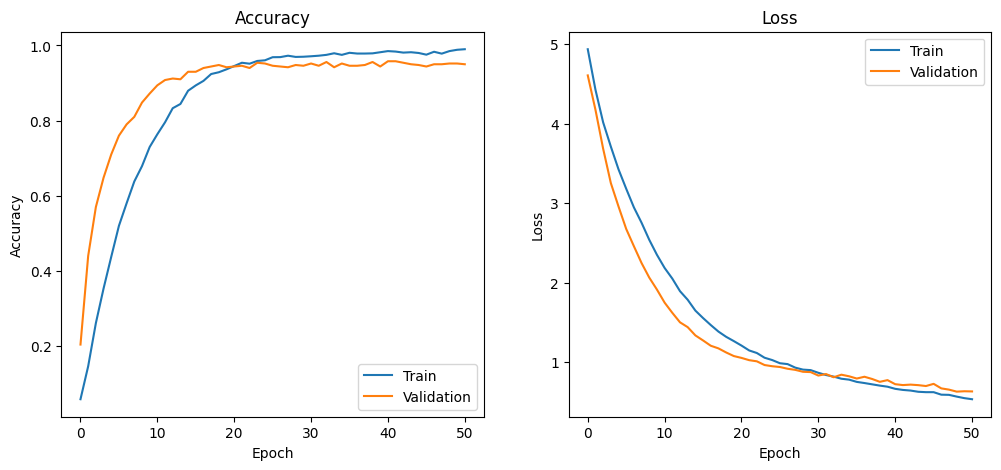

In [12]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


<Figure size 1200x1200 with 0 Axes>

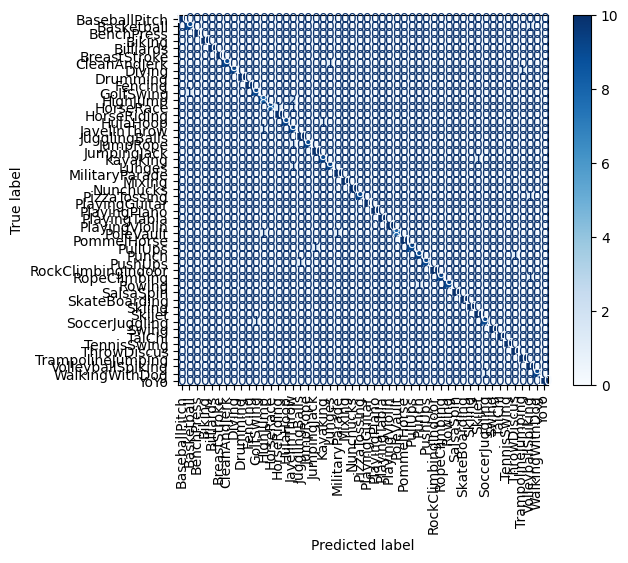

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=SELECTED_CLASSES
)

plt.figure(figsize=(12,12))
disp.plot(cmap="Blues", xticks_rotation=90)
plt.show()

In [14]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=SELECTED_CLASSES
))

                    precision    recall  f1-score   support

     BaseballPitch       1.00      1.00      1.00        10
        Basketball       0.90      0.90      0.90        10
        BenchPress       1.00      1.00      1.00        10
            Biking       1.00      1.00      1.00        10
         Billiards       1.00      1.00      1.00        10
      BreastStroke       1.00      1.00      1.00        10
      CleanAndJerk       1.00      0.90      0.95        10
            Diving       1.00      0.90      0.95        10
          Drumming       1.00      1.00      1.00        10
           Fencing       1.00      1.00      1.00        10
         GolfSwing       0.90      0.90      0.90        10
          HighJump       0.80      0.80      0.80        10
         HorseRace       1.00      0.80      0.89        10
       HorseRiding       0.91      1.00      0.95        10
          HulaHoop       1.00      0.90      0.95        10
      JavelinThrow       0.64      0.90